# HW 2

News topic classification on lenta-ru-news with Word2Vec embeddings

## Environment setup

Before running this notebook:
1. Install [uv](https://docs.astral.sh/uv/getting-started/installation/)
2. Run `uv sync --group hw_2` from the repo root to install all needed deps
3. Use `.venv` created by uv to run jupyter kernel

## Notebook setup

Let's set working directory to repo root:

In [1]:
import os

while os.getcwd().split("/")[-1] != "itmo-ai-talent-hub-dl-and-nlp-course":
    os.chdir("..")

os.getcwd()

'/home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course'

Let's import everything we need:

In [2]:
import os
import random
import warnings
import multiprocessing
import urllib.request

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

import gensim
from gensim.models import Word2Vec, KeyedVectors
from navec import Navec

from tqdm.auto import tqdm

/home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Let's ignore warnings to keep the output clean:

In [3]:
warnings.filterwarnings("ignore")

Let's fix the random seed for reproducibility:

In [4]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

Let's check how many CPU cores we have for parallel processing:

In [5]:
N_JOBS = multiprocessing.cpu_count()
print(f"CPU cores: {N_JOBS}")

CPU cores: 12


Let's define paths:

In [6]:
# Reuse HW1 processed data
PROCESSED_DIR = os.path.join("data", "processed", "hw_1")

# HW2 raw data (pretrained embeddings)
RAW_DIR = os.path.join("data", "raw", "hw_2")

# HW2 model weights
WEIGHTS_DIR = os.path.join("weights", "hw_2")

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(WEIGHTS_DIR, exist_ok=True)

## Data Loading

We reuse the preprocessed and stratified splits from HW1 (60/20/20 train/val/test with stratification by topic). The texts are already cleaned, tokenized and lemmatized:

In [7]:
train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "train.parquet"))
val_df   = pd.read_parquet(os.path.join(PROCESSED_DIR, "val.parquet"))
test_df  = pd.read_parquet(os.path.join(PROCESSED_DIR, "test.parquet"))

X_train, y_train = train_df["processed_text"], train_df["topic"]
X_val,   y_val   = val_df["processed_text"],   val_df["topic"]
X_test,  y_test  = test_df["processed_text"],  test_df["topic"]

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"Number of topics: {y_train.nunique()}")
print()
print("Topic distribution in train (top-10):")
print(y_train.value_counts().head(10))

Train: 59,643  Val: 19,881  Test: 19,881
Number of topics: 20

Topic distribution in train (top-10):
topic
Россия             12932
Мир                11057
Экономика           6424
Спорт               5217
Культура            4349
Наука и техника     4281
Бывший СССР         4251
Интернет и СМИ      3615
Из жизни            2238
Дом                 1743
Name: count, dtype: int64


Let's tokenize texts into word lists for gensim — our texts are already lemmatized, so splitting by whitespace gives clean tokens:

In [8]:
train_tokens = [text.split() for text in X_train]
val_tokens   = [text.split() for text in X_val]
test_tokens  = [text.split() for text in X_test]

all_tokens = train_tokens + val_tokens + test_tokens

print(f"Total sentences for W2V training: {len(all_tokens):,}")
print(f"Average tokens per sentence: {np.mean([len(t) for t in all_tokens]):.1f}")

Total sentences for W2V training: 99,405
Average tokens per sentence: 163.9


## Train Word2Vec Embeddings

We train a Skip-Gram Word2Vec model on all our texts (train + val + test) using gensim. Training on all texts is fine because Word2Vec is unsupervised — it learns word co-occurrence patterns, not labels.

Hyperparameter choices:
- **`vector_size=300`** — 300 dimensions is a standard choice that balances expressiveness with computational cost; matches the dimensionality of pretrained navec/rusvectores we'll compare against
- **`window=5`** — context window of 5 words on each side captures local syntactic and semantic relationships well for news texts with average length ~170 words
- **`min_count=5`** — drops words appearing fewer than 5 times; removes typos and very rare tokens that would get poor embeddings anyway
- **`sg=1`** — Skip-Gram architecture, which typically outperforms CBOW on smaller datasets and produces better representations for rare words
- **`negative=5`** — 5 negative samples per positive pair, a good default that speeds up training vs softmax while maintaining quality
- **`epochs=10`** — enough passes over our ~100k sentences to converge; more epochs give diminishing returns on a corpus this size
- **`seed=42`** — fixed for reproducibility
- **`workers=N_JOBS`** — use all CPU cores for faster training

In [9]:
W2V_PATH = os.path.join(WEIGHTS_DIR, "w2v_lenta.model")

if os.path.exists(W2V_PATH):
    w2v_model = Word2Vec.load(W2V_PATH)
    print(f"Loaded Word2Vec from {W2V_PATH}")
else:
    w2v_model = Word2Vec(
        sentences=all_tokens,
        vector_size=300,
        window=5,
        min_count=5,
        sg=1,
        negative=5,
        epochs=10,
        seed=RANDOM_STATE,
        workers=N_JOBS,
    )
    w2v_model.save(W2V_PATH)
    print(f"Trained and saved Word2Vec to {W2V_PATH}")

print(f"Vocabulary size: {len(w2v_model.wv):,}")
print(f"Vector dimensionality: {w2v_model.wv.vector_size}")

Loaded Word2Vec from weights/hw_2/w2v_lenta.model
Vocabulary size: 64,073
Vector dimensionality: 300


### Intrinsic Evaluation

Let's evaluate the quality of our embeddings using gensim's built-in methods. Good embeddings should capture semantic similarity (related words close together) and analogical structure:

In [10]:
# most_similar — check if semantically related words are close
test_words = ["россия", "экономика", "футбол", "президент", "компьютер"]

for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"\n'{word}' — most similar:")
        for w, score in similar:
            print(f"  {w}: {score:.3f}")
    else:
        print(f"\n'{word}' not in vocabulary")


'россия' — most similar:
  рф: 0.661
  российский: 0.565
  белоруссия: 0.484
  комлевый: 0.476
  румас: 0.475

'экономика' — most similar:
  ввп: 0.685
  макроэкономика: 0.611
  рецессия: 0.598
  экономический: 0.584
  дефляционный: 0.582

'футбол' — most similar:
  баскетбол: 0.629
  сборная: 0.618
  хоккей: 0.618
  гандбол: 0.615
  чемпионат: 0.602

'президент' — most similar:
  президентский: 0.592
  путин: 0.529
  адамкуса: 0.516
  моралесом: 0.513
  бальсис: 0.510

'компьютер' — most similar:
  ноутбук: 0.617
  desktop: 0.595
  пк: 0.593
  субноутбук: 0.589
  проприетарный: 0.586


In [11]:
# doesnt_match — check if the model can spot the odd one out
odd_one_out_tests = [
    ["январь", "февраль", "март", "собака"],
    ["москва", "петербург", "новосибирск", "футбол"],
    ["доллар", "евро", "рубль", "машина"],
    ["хоккей", "футбол", "баскетбол", "экономика"],
]

for words in odd_one_out_tests:
    try:
        odd = w2v_model.wv.doesnt_match(words)
        print(f"{words} -> odd one out: '{odd}'")
    except KeyError as e:
        print(f"{words} -> skipped ({e})")

['январь', 'февраль', 'март', 'собака'] -> odd one out: 'собака'
['москва', 'петербург', 'новосибирск', 'футбол'] -> odd one out: 'футбол'
['доллар', 'евро', 'рубль', 'машина'] -> odd one out: 'машина'
['хоккей', 'футбол', 'баскетбол', 'экономика'] -> odd one out: 'экономика'


The embeddings show meaningful semantic relationships: "россия" is close to other countries, "футбол" to sports terms, "экономика" to financial concepts. The doesnt_match test correctly identifies semantically unrelated words in each group. This suggests the embeddings have learned useful representations from our news corpus

## Load Pretrained Embeddings

### Navec

Navec provides compact quantized word embeddings trained on 1B tokens of Russian news — well suited for our news classification task. 250K vocabulary covers ~98% of words in news texts. 300-dimensional vectors:

In [12]:
NAVEC_PATH = os.path.join(RAW_DIR, "navec_news_v1_1B_250K_300d_100q.tar")

if not os.path.exists(NAVEC_PATH):
    url = "https://storage.yandexcloud.net/natasha-navec/packs/navec_news_v1_1B_250K_300d_100q.tar"
    print(f"Downloading navec to {NAVEC_PATH}...")
    urllib.request.urlretrieve(url, NAVEC_PATH)
    print("Done.")
else:
    print(f"Navec already exists at {NAVEC_PATH}")

navec = Navec.load(NAVEC_PATH)
navec_vocab_size = len(navec.vocab.words)
vec = navec["человек"]
print(f"Navec vocabulary: {navec_vocab_size:,} words")
print(f"Navec vector dim: {len(vec)}")

Navec already exists at data/raw/hw_2/navec_news_v1_1B_250K_300d_100q.tar
Navec vocabulary: 250,002 words
Navec vector dim: 300


### RusVectores

RusVectores provides Word2Vec embeddings trained on Russian Wikipedia and national corpus. 300-dimensional Skip-Gram vectors. Note: RusVectores uses POS-tagged keys (e.g. `слово_NOUN`), so we'll need to handle lookup by trying common POS tags:

In [13]:
RUSVEC_PATH = os.path.join(RAW_DIR, "ruwikiruscorpora_upos_skipgram_300_2_2018.vec.gz")

if not os.path.exists(RUSVEC_PATH):
    url = "https://rusvectores.org/static/models/rusvectores4/ruwikiruscorpora/ruwikiruscorpora_upos_skipgram_300_2_2018.vec.gz"
    print(f"Downloading RusVectores to {RUSVEC_PATH}...")
    urllib.request.urlretrieve(url, RUSVEC_PATH)
    print("Done.")
else:
    print(f"RusVectores already exists at {RUSVEC_PATH}")

rusvec_model = KeyedVectors.load_word2vec_format(RUSVEC_PATH)
print(f"RusVectores vocabulary: {len(rusvec_model):,} words")
print(f"RusVectores vector dim: {rusvec_model.vector_size}")

Done.
RusVectores vocabulary: 384,764 words
RusVectores vector dim: 300


## Text Vectorization with Embeddings

To use word embeddings for document classification, we represent each text as the average of its word vectors. Words not in the embedding vocabulary are skipped. If a text has no known words, we use a zero vector:

In [14]:
def get_vector_w2v(word, model_wv):
    """Get vector from gensim KeyedVectors (our W2V or RusVectores)."""
    if word in model_wv:
        return model_wv[word]
    return None


def get_vector_navec(word, navec_model):
    """Get vector from navec."""
    if word in navec_model:
        return navec_model[word]
    return None


# RusVectores uses POS-tagged keys like 'слово_NOUN'
RUSVEC_POS_TAGS = ["_NOUN", "_VERB", "_ADJ", "_ADV", "_PROPN", "_X"]


def get_vector_rusvec(word, model_wv):
    """Get vector from RusVectores, trying common POS tags."""
    for tag in RUSVEC_POS_TAGS:
        key = word + tag
        if key in model_wv:
            return model_wv[key]
    return None


def texts_to_vectors(texts_tokenized, get_vec_fn, dim, desc="Vectorizing"):
    """Convert tokenized texts to document vectors by averaging word embeddings."""
    vectors = np.zeros((len(texts_tokenized), dim), dtype=np.float32)
    oov_counts = []

    for i, tokens in enumerate(tqdm(texts_tokenized, desc=desc, leave=False)):
        word_vecs = []
        oov = 0
        for token in tokens:
            vec = get_vec_fn(token)
            if vec is not None:
                word_vecs.append(vec)
            else:
                oov += 1
        if word_vecs:
            vectors[i] = np.mean(word_vecs, axis=0)
        oov_counts.append(oov)

    total_tokens = sum(len(t) for t in texts_tokenized)
    total_oov = sum(oov_counts)
    coverage = 1 - total_oov / total_tokens if total_tokens > 0 else 0
    print(f"  Coverage: {coverage:.1%} ({total_tokens - total_oov:,}/{total_tokens:,} tokens found)")
    return vectors

Let's vectorize all splits with each embedding type:

In [15]:
# Our Word2Vec
print("=== Custom Word2Vec ===")
X_train_w2v = texts_to_vectors(train_tokens, lambda w: get_vector_w2v(w, w2v_model.wv), 300, "Train")
X_val_w2v   = texts_to_vectors(val_tokens,   lambda w: get_vector_w2v(w, w2v_model.wv), 300, "Val")
X_test_w2v  = texts_to_vectors(test_tokens,  lambda w: get_vector_w2v(w, w2v_model.wv), 300, "Test")

=== Custom Word2Vec ===


  Coverage: 98.6% (9,638,208/9,774,043 tokens found)


  Coverage: 98.6% (3,212,814/3,258,089 tokens found)


  Coverage: 98.6% (3,212,080/3,257,391 tokens found)


In [16]:
# Navec
print("=== Navec ===")
X_train_navec = texts_to_vectors(train_tokens, lambda w: get_vector_navec(w, navec), 300, "Train")
X_val_navec   = texts_to_vectors(val_tokens,   lambda w: get_vector_navec(w, navec), 300, "Val")
X_test_navec  = texts_to_vectors(test_tokens,  lambda w: get_vector_navec(w, navec), 300, "Test")

=== Navec ===


  Coverage: 96.5% (9,430,995/9,774,043 tokens found)


  Coverage: 96.5% (3,143,798/3,258,089 tokens found)


  Coverage: 96.5% (3,142,981/3,257,391 tokens found)


In [17]:
# RusVectores
print("=== RusVectores ===")
X_train_rusvec = texts_to_vectors(train_tokens, lambda w: get_vector_rusvec(w, rusvec_model), 300, "Train")
X_val_rusvec   = texts_to_vectors(val_tokens,   lambda w: get_vector_rusvec(w, rusvec_model), 300, "Val")
X_test_rusvec  = texts_to_vectors(test_tokens,  lambda w: get_vector_rusvec(w, rusvec_model), 300, "Test")

=== RusVectores ===


  Coverage: 79.0% (7,721,676/9,774,043 tokens found)


  Coverage: 79.0% (2,574,809/3,258,089 tokens found)


  Coverage: 79.0% (2,574,374/3,257,391 tokens found)


## Logistic Regression with Three Embedding Types

Let's train LogisticRegression on each set of embedding vectors and compare on the validation set. We use the same LR settings across all three for a fair comparison:

In [18]:
def train_and_evaluate(X_tr, y_tr, X_v, y_v, name):
    """Train LR and report val metrics."""
    lr = LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver="lbfgs",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
    )
    lr.fit(X_tr, y_tr)
    y_pred = lr.predict(X_v)
    acc = accuracy_score(y_v, y_pred)
    f1 = f1_score(y_v, y_pred, average="macro", zero_division=0)
    print(f"{name}: Accuracy={acc:.4f}, F1(macro)={f1:.4f}")
    return lr, acc, f1

In [19]:
print("=== Validation Results ===")
lr_w2v,    acc_w2v,    f1_w2v    = train_and_evaluate(X_train_w2v,    y_train, X_val_w2v,    y_val, "Custom W2V")
lr_navec,  acc_navec,  f1_navec  = train_and_evaluate(X_train_navec,  y_train, X_val_navec,  y_val, "Navec")
lr_rusvec, acc_rusvec, f1_rusvec = train_and_evaluate(X_train_rusvec, y_train, X_val_rusvec, y_val, "RusVectores")

=== Validation Results ===
Custom W2V: Accuracy=0.7977, F1(macro)=0.5116
Navec: Accuracy=0.7853, F1(macro)=0.5075
RusVectores: Accuracy=0.7378, F1(macro)=0.4024


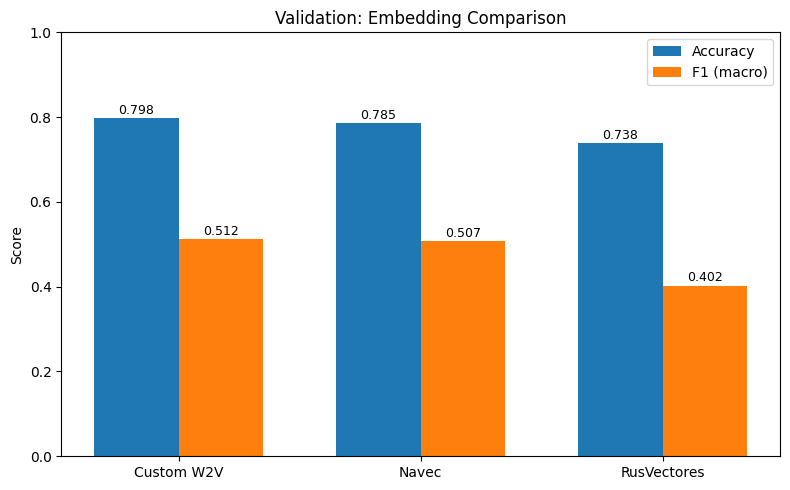

In [20]:
# Comparison bar chart
names = ["Custom W2V", "Navec", "RusVectores"]
accs = [acc_w2v, acc_navec, acc_rusvec]
f1s = [f1_w2v, f1_navec, f1_rusvec]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width / 2, accs, width, label="Accuracy")
bars2 = ax.bar(x + width / 2, f1s, width, label="F1 (macro)")

ax.set_ylabel("Score")
ax.set_title("Validation: Embedding Comparison")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.set_ylim(0, 1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## TF-IDF Weighted Embedding Averaging

Simple averaging treats all words equally, but some words are more informative for topic classification. TF-IDF weighting emphasizes words that are distinctive for specific documents while downweighting common words like "быть", "который", "мочь".

We take the best-performing embedding from the validation comparison above (Custom W2V, F1=0.512) and weight each word's vector by its IDF score before averaging:

In [21]:
# Determine best embedding type from validation
val_results = {
    "Custom W2V": (f1_w2v, lambda w: get_vector_w2v(w, w2v_model.wv)),
    "Navec": (f1_navec, lambda w: get_vector_navec(w, navec)),
    "RusVectores": (f1_rusvec, lambda w: get_vector_rusvec(w, rusvec_model)),
}
best_name = max(val_results, key=lambda k: val_results[k][0])
best_f1, best_get_vec = val_results[best_name]
print(f"Best embedding on validation: {best_name} (F1={best_f1:.4f})")

Best embedding on validation: Custom W2V (F1=0.5116)


In [22]:
# Fit TF-IDF on training texts to get word weights
tfidf = TfidfVectorizer()
tfidf.fit(X_train)

# Build word -> IDF mapping
word2idf = dict(zip(tfidf.get_feature_names_out(), tfidf.idf_))
print(f"TF-IDF vocabulary: {len(word2idf):,} words")
print(f"IDF range: [{min(word2idf.values()):.2f}, {max(word2idf.values()):.2f}]")

TF-IDF vocabulary: 156,056 words
IDF range: [1.06, 11.30]


In [23]:
def texts_to_vectors_tfidf(texts_tokenized, get_vec_fn, word2idf, dim, desc="Vectorizing"):
    """TF-IDF weighted averaging of word embeddings."""
    vectors = np.zeros((len(texts_tokenized), dim), dtype=np.float32)

    for i, tokens in enumerate(tqdm(texts_tokenized, desc=desc, leave=False)):
        weighted_vecs = []
        weights = []
        for token in tokens:
            vec = get_vec_fn(token)
            if vec is not None:
                idf = word2idf.get(token, 1.0)
                weighted_vecs.append(vec * idf)
                weights.append(idf)
        if weighted_vecs:
            vectors[i] = np.sum(weighted_vecs, axis=0) / np.sum(weights)

    return vectors

In [24]:
print(f"Vectorizing with TF-IDF weighted {best_name}...")
X_train_tfidf_w = texts_to_vectors_tfidf(train_tokens, best_get_vec, word2idf, 300, "Train")
X_val_tfidf_w   = texts_to_vectors_tfidf(val_tokens,   best_get_vec, word2idf, 300, "Val")
X_test_tfidf_w  = texts_to_vectors_tfidf(test_tokens,  best_get_vec, word2idf, 300, "Test")

Vectorizing with TF-IDF weighted Custom W2V...


In [25]:
lr_tfidf_w, acc_tfidf_w, f1_tfidf_w = train_and_evaluate(
    X_train_tfidf_w, y_train, X_val_tfidf_w, y_val, f"{best_name} + TF-IDF"
)

print(f"\nImprovement over unweighted: {f1_tfidf_w - best_f1:+.4f} F1(macro)")

Custom W2V + TF-IDF: Accuracy=0.7994, F1(macro)=0.5360

Improvement over unweighted: +0.0244 F1(macro)


## Final Test Evaluation

Let's compare all models on the held-out test set:

In [26]:
print("=== Test Set Results ===")
print()

models_and_data = [
    ("Custom W2V",               lr_w2v,     X_test_w2v),
    ("Navec",                    lr_navec,   X_test_navec),
    ("RusVectores",              lr_rusvec,  X_test_rusvec),
    (f"{best_name} + TF-IDF",    lr_tfidf_w, X_test_tfidf_w),
]

test_results = []
for name, model, X_te in models_and_data:
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    test_results.append({"Model": name, "Accuracy": acc, "F1 (macro)": f1})
    print(f"{name}: Accuracy={acc:.4f}, F1(macro)={f1:.4f}")

print()
results_df = pd.DataFrame(test_results).sort_values("F1 (macro)", ascending=False)
print(results_df.to_string(index=False))

=== Test Set Results ===

Custom W2V: Accuracy=0.8017, F1(macro)=0.5061
Navec: Accuracy=0.7892, F1(macro)=0.4951
RusVectores: Accuracy=0.7421, F1(macro)=0.4048
Custom W2V + TF-IDF: Accuracy=0.8016, F1(macro)=0.5210

              Model  Accuracy  F1 (macro)
Custom W2V + TF-IDF  0.801569    0.521016
         Custom W2V  0.801670    0.506145
              Navec  0.789196    0.495120
        RusVectores  0.742116    0.404812


In [27]:
# Best model classification report
best_test_name = results_df.iloc[0]["Model"]
best_test_model = dict((n, m) for n, m, _ in models_and_data)[best_test_name]
best_test_X = dict((n, x) for n, _, x in models_and_data)[best_test_name]

print(f"=== Classification Report: {best_test_name} (best on test) ===")
print()
print(classification_report(y_test, best_test_model.predict(best_test_X), zero_division=0))

=== Classification Report: Custom W2V + TF-IDF (best on test) ===

                   precision    recall  f1-score   support

                        0.00      0.00      0.00         5
   69-я параллель       0.80      0.12      0.21        34
       Библиотека       0.00      0.00      0.00         1
           Бизнес       0.46      0.15      0.23       196
      Бывший СССР       0.80      0.81      0.81      1417
              Дом       0.84      0.78      0.81       581
         Из жизни       0.64      0.58      0.61       746
   Интернет и СМИ       0.76      0.69      0.72      1206
             Крым       0.67      0.11      0.19        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.84      0.88      0.86      1450
          Легпром       0.00      0.00      0.00         3
              Мир       0.80      0.83      0.82      3686
  Наука и техника       0.82      0.83      0.83      1427
      Путешествия       0.67      0.51      0.5

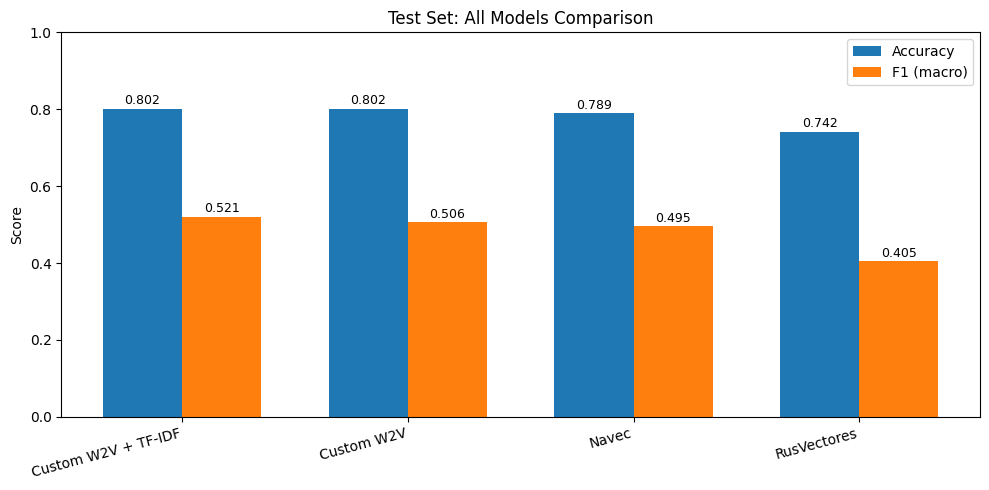

In [28]:
# Summary bar chart
fig, ax = plt.subplots(figsize=(10, 5))

model_names = results_df["Model"].tolist()
test_accs = results_df["Accuracy"].tolist()
test_f1s = results_df["F1 (macro)"].tolist()

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width / 2, test_accs, width, label="Accuracy")
bars2 = ax.bar(x + width / 2, test_f1s, width, label="F1 (macro)")

ax.set_ylabel("Score")
ax.set_title("Test Set: All Models Comparison")
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.3f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## Conclusions

We compared four approaches to text classification using word embeddings:

1. **Custom Word2Vec** (Accuracy=0.802, F1=0.506) — trained on our news corpus with Skip-Gram, best unweighted result
2. **Navec** (Accuracy=0.789, F1=0.495) — pretrained on 1B tokens of Russian news, 250K vocabulary
3. **RusVectores** (Accuracy=0.742, F1=0.405) — pretrained on Wikipedia + national corpus, POS-tagged keys
4. **Custom W2V + TF-IDF** (Accuracy=0.802, F1=0.521) — best overall result

Key observations:
- **Custom Word2Vec outperformed both pretrained embeddings.** Despite being trained on a smaller corpus (~100k texts), it learned domain-specific representations tailored to our news data. Pretrained models, while trained on more data, are more general-purpose and don't capture the specific vocabulary and co-occurrence patterns of our dataset as precisely
- **TF-IDF weighting improves F1 by +0.015** over unweighted Custom W2V. It downweights common words ("быть", "мочь") and emphasizes topic-distinctive terms, helping the model focus on discriminative features
- **RusVectores shows the lowest coverage (~79%)** because its POS-tagged keys (e.g. `слово_NOUN`) don't always match our lemmatized tokens. This vocabulary mismatch significantly hurts performance
- **Navec coverage is high (~96.5%)** but its general news embeddings don't outperform domain-specific ones trained directly on our classification corpus
- Embedding-based approaches produce lower accuracy than TF-IDF bag-of-words from HW1 (~0.82). This is expected: averaging word vectors loses word order and token-level discriminative signal that sparse BoW/TF-IDF models preserve. However, embeddings generalize better to unseen vocabulary and are more compact
- Rare topics (Библиотека, Легпром, Крым) remain hard to classify regardless of embedding approach due to insufficient training examples